In [2]:
import numpy as np
import matplotlib.pyplot as plt

deg2rad = np.pi / 180.0
rad2deg = 180.0 / np.pi

R = 6.96e8
dt = 0.001
diff_values = [200, 400, 600, 800]
polar_flux_all_n = []
polar_flux_all_s = []
polar_flux_all_t = []
time_axis = None
dphi = 2*deg2rad
dtheta1_d = 2*3
dtheta2_d = 3
dtheta3_d = 2
tot_time = 365
N_steps = int(tot_time / dt)
save = 100
N_save = int(N_steps / save)+1
N_phi = int(2*np.pi/ dphi)
v_mer_ms = 15
v_mer_max = v_mer_ms * 24*60*60
omega_max_deg = 13.38
omega_max = omega_max_deg*deg2rad

theta_1n = np.arange(5, 30, dtheta1_d)
theta_2n = np.arange(30, 60, dtheta2_d)
theta_3 = np.arange(60, 120, dtheta3_d)
theta_2s = np.arange(120, 150, dtheta2_d)
theta_1s = np.arange(150, 180 - 5, dtheta1_d)


print("theta_1n:", theta_1n.shape)
print("theta_2n:", theta_2n.shape)  
print("theta_3:", theta_3.shape)
print("theta_2s:", theta_2s.shape)
print("theta_1s:", theta_1s.shape)

N_theta = (len(theta_1n) + len(theta_2n) + len(theta_3) + len(theta_2s) + len(theta_1s))
theta_deg = np.concatenate((theta_1n, theta_2n, theta_3, theta_2s, theta_1s))

theta = theta_deg * deg2rad
dtheta1 = dtheta1_d * deg2rad
dtheta2 = dtheta2_d * deg2rad
dtheta3 = dtheta3_d * deg2rad

delta_x = R*np.min(np.sin(theta))*dphi
delta_y = R*dtheta3

phi = np.arange(0, 2 * np.pi, dphi)
Phi, Theta = np.meshgrid(phi, theta)

Phi_deg = Phi * rad2deg
Theta_deg = Theta * rad2deg

theta_1n: (5,)
theta_2n: (10,)
theta_3: (30,)
theta_2s: (10,)
theta_1s: (5,)


In [3]:
(4*deg2rad)**2

0.004873878716587337

In [4]:
np.min(np.sin(theta))

np.float64(0.08715574274765817)

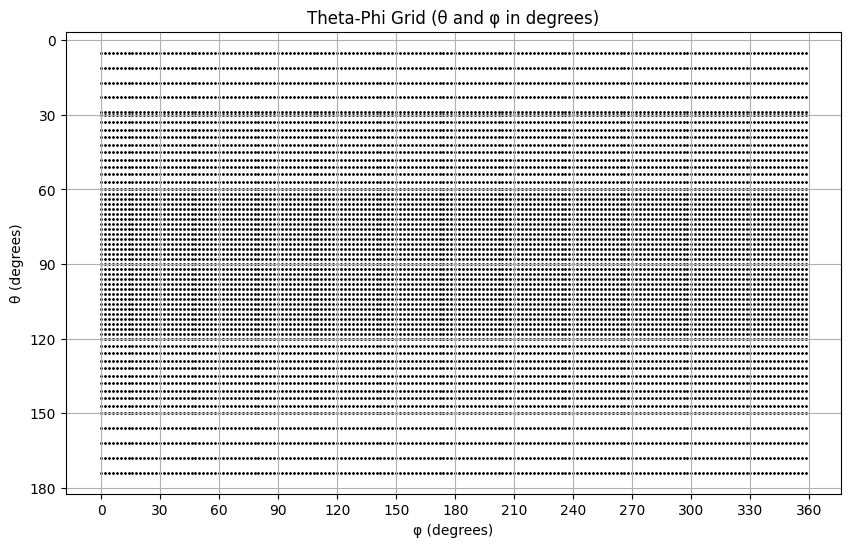

In [5]:
plt.figure(figsize=(10, 6))
plt.scatter(Phi_deg, Theta_deg, s=1, color='black')
plt.xlabel("φ (degrees)")
plt.ylabel("θ (degrees)")
plt.gca().invert_yaxis()
plt.title("Theta-Phi Grid (θ and φ in degrees)")
plt.xticks(np.arange(0, 361, 30))
plt.yticks(np.arange(0, 181, 30))
plt.grid(True)
plt.show()

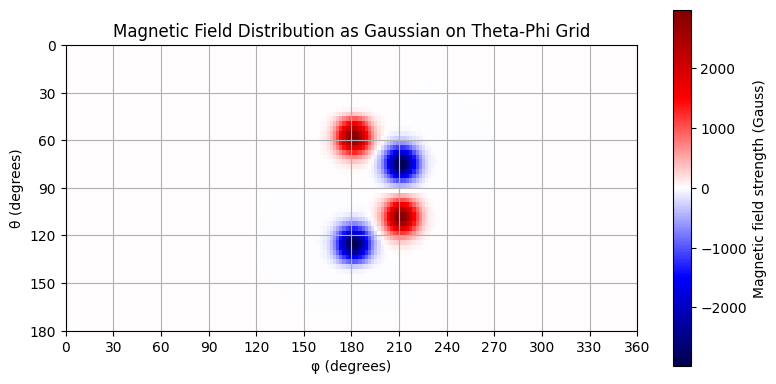

In [6]:
sigma_t = 5 * deg2rad
sigma_p = 7.07 * deg2rad 
T_plus_1 = 3000*np.exp(-0.5*(((Theta - (9*np.pi/24) )/sigma_t)**2+((Phi - np.pi*(6/6))/sigma_p)**2))
T_minus_1 = -3000*np.exp(-0.5*(((Theta - (10.5*np.pi/24) )/sigma_t)**2+((Phi - np.pi*(7/6))/sigma_p)**2))
T_plus_2 = 3000*np.exp(-0.5*(((Theta - (13.5*np.pi/24) )/sigma_t)**2+((Phi - np.pi*(7/6))/sigma_p)**2))
T_minus_2 = -3000*np.exp(-0.5*(((Theta - (15*np.pi/24) )/sigma_t)**2+((Phi - np.pi*(6/6))/sigma_p)**2))
T = T_plus_1 + T_minus_1 + T_plus_2 + T_minus_2
plt.figure(figsize=(8, 4))
plt.imshow(T, extent=(0, 360, 0, 180), aspect='equal', origin='lower', cmap='seismic')
plt.colorbar(label='Magnetic field strength (Gauss)')
plt.xlabel("φ (degrees)")
plt.ylabel("θ (degrees)")
plt.gca().invert_yaxis()
plt.title("Magnetic Field Distribution as Gaussian on Theta-Phi Grid")
plt.xticks(np.arange(0, 361, 30))
plt.yticks(np.arange(0, 181, 30))
plt.grid(True)
plt.tight_layout()
plt.show()

In [7]:
N_phi, N_theta

(180, 60)

In [8]:
Phi.shape

(60, 180)

In [9]:
dtheta_rad = np.zeros(N_theta)
dtheta_rad[:len(theta_1n)] = dtheta1
dtheta_rad[len(theta_1n):len(theta_1n) + len(theta_2n)] = dtheta2
dtheta_rad[len(theta_1n) + len(theta_2n):len(theta_1n) + len(theta_2n) + len(theta_3)] = dtheta3
dtheta_rad[len(theta_1n) + len(theta_2n) + len(theta_3):len(theta_1n) + len(theta_2n) + len(theta_3) + len(theta_2s)] = dtheta2
dtheta_rad[len(theta_1n) + len(theta_2n) + len(theta_3) + len(theta_2s):] = dtheta1

In [10]:
dtheta_rad

array([0.10471976, 0.10471976, 0.10471976, 0.10471976, 0.10471976,
       0.05235988, 0.05235988, 0.05235988, 0.05235988, 0.05235988,
       0.05235988, 0.05235988, 0.05235988, 0.05235988, 0.05235988,
       0.03490659, 0.03490659, 0.03490659, 0.03490659, 0.03490659,
       0.03490659, 0.03490659, 0.03490659, 0.03490659, 0.03490659,
       0.03490659, 0.03490659, 0.03490659, 0.03490659, 0.03490659,
       0.03490659, 0.03490659, 0.03490659, 0.03490659, 0.03490659,
       0.03490659, 0.03490659, 0.03490659, 0.03490659, 0.03490659,
       0.03490659, 0.03490659, 0.03490659, 0.03490659, 0.03490659,
       0.05235988, 0.05235988, 0.05235988, 0.05235988, 0.05235988,
       0.05235988, 0.05235988, 0.05235988, 0.05235988, 0.05235988,
       0.10471976, 0.10471976, 0.10471976, 0.10471976, 0.10471976])

In [11]:
print(T.shape)
T = T.T
print(T.shape)

(60, 180)
(180, 60)


In [12]:
omega = omega_max - (2.3 * (np.cos(theta))**2 - 1.62* (np.cos(theta))**4) * deg2rad

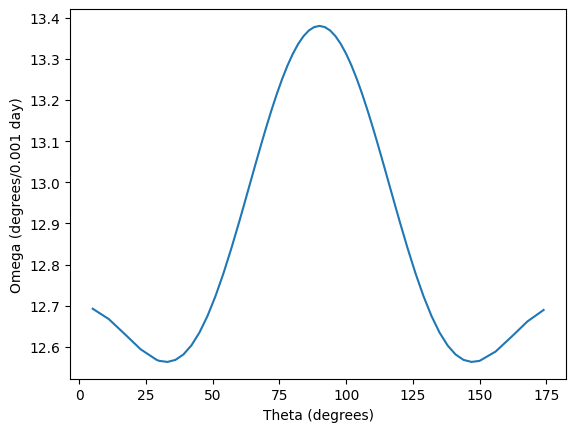

In [13]:
plt.plot(theta_deg, omega * rad2deg)
plt.xlabel("Theta (degrees)")
plt.ylabel(f"Omega (degrees/{dt} day)")
plt.show()

In [14]:
col = theta*rad2deg-90
v_mer = np.where(np.abs(col)<=75, v_mer_max * np.sin(np.pi * col / 75), 0)

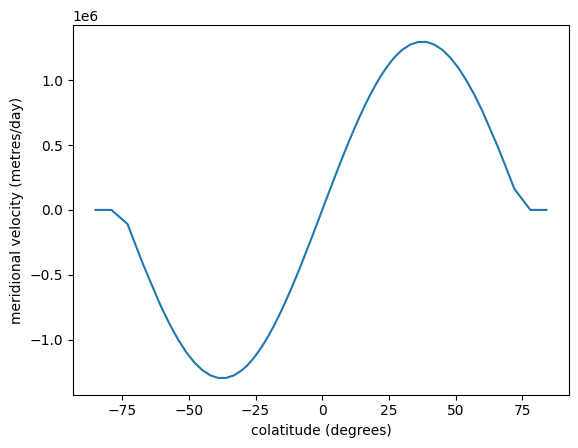

In [15]:
plt.plot(col, v_mer)
plt.xlabel("colatitude (degrees)")
plt.ylabel("meridional velocity (metres/day)")
plt.show()

In [16]:
cot = 1/np.tan(theta)
sin2 = (np.sin(theta))**2
senin = 1/(np.sin(theta))
cos = np.cos(theta)
sin = np.sin(theta)
all_values = np.zeros((N_save, N_phi, N_theta),dtype=np.float32)
all_values[0, :, :] = T
T_new = np.zeros_like(T)
T_new.shape

(180, 60)

In [17]:
north_cap = theta_deg<= 30
south_cap = theta_deg>= 150

element_area = (R**2) * sin * dtheta_rad * dphi

flux_north = []
flux_south = []
flux_total = []
time_days = []

In [18]:
accum_bottom = np.zeros(N_phi)
accum_top = np.zeros(N_phi)
save_idx = 0
all_values[save_idx, :, :]  = T
all_values[save_idx, :, 0]  = accum_bottom
all_values[save_idx, :, -1] = accum_top
save_idx += 1


Running for diffusion = 200
stab_par: 0.06486665347920646
alpha: 17280000000000.0

Running for diffusion = 400
stab_par: 0.03243332673960323
alpha: 34560000000000.0

Running for diffusion = 600
stab_par: 0.021622217826402154
alpha: 51840000000000.0

Running for diffusion = 800
stab_par: 0.016216663369801616
alpha: 69120000000000.0


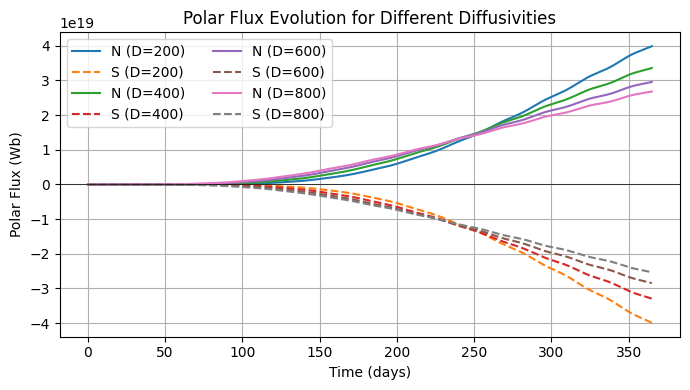

In [19]:
# -------------------------------
# DIFFUSION VALUES SETUP
# -------------------------------
diff_values = [200, 400, 600, 800]

polar_flux_all_n = []
polar_flux_all_s = []
polar_flux_all_t = []
time_axis = None

# ===============================
# PARAMETER SWEEP LOOP
# ===============================
for diff_const in diff_values:

    print(f"\nRunning for diffusion = {diff_const}")

    alpha = diff_const *1e6 * 24*60*60
    stab_par = min((min(delta_x**2,delta_y**2))/(4*alpha), delta_y/v_mer_max, dphi/omega_max)
    print(f"stab_par: {stab_par}")
    assert dt <= stab_par, "Stability condition violated!!!!!!!!!!!"
    print("alpha:", alpha)

    # -------------------------------
    # INITIAL CONDITION (RESET!)
    # -------------------------------
    T = T_plus_1 + T_minus_1 + T_plus_2 + T_minus_2

    T = T.T
    T_new = np.zeros_like(T)

    accum_bottom = np.zeros(N_phi)
    accum_top = np.zeros(N_phi)

    all_values = np.zeros((N_save, N_phi, N_theta),dtype=np.float32)

    flux_north = []
    flux_south = []
    flux_total = []
    time_days = []

    save_idx = 0
    all_values[save_idx, :, :]  = T
    all_values[save_idx, :, 0]  = accum_bottom
    all_values[save_idx, :, -1] = accum_top
    save_idx += 1

    # ===============================
    # TIME LOOP
    # ===============================
    for n in range(1, N_steps + 1):

        t_days = n * dt

        i_sl = slice(1, -1)
        j_sl = slice(1, -1)

        Tc   = T[i_sl, j_sl]                 
        T_ip = T[2:,  j_sl]                  
        T_im = T[:-2, j_sl]                 
        T_jp = T[i_sl, 2:]                   
        T_jm = T[i_sl, :-2]                  

        dth     = dtheta_rad[1:-1]         
        inv_dth = 1.0 / dth
        inv_dth2= inv_dth**2
        sin_i   = sin[1:-1]
        sin2_i  = sin2[1:-1]
        cos_i   = cos[1:-1]
        cot_i   = cot[1:-1]
        sin_c    = sin[1:-1]                   
        sin_ph   = sin[2:]                      
        sin_mh   = sin[:-2]                    
        omg_c    = omega[1:-1]                  
        v_ph     = 0.5*(v_mer[1:-1] + v_mer[2:])  
        v_mh     = 0.5*(v_mer[:-2]  + v_mer[1:-1]) 

        eps = 1e-1
        sin_i_safe  = np.maximum(sin_i,  eps)
        sin2_i_safe = np.maximum(sin2_i, eps**2)
        cot_i_safe = np.maximum(cot_i, eps)

        d2T_dtheta = (T_jp - 2.0 * Tc + T_jm) * inv_dth2
        cot_term   = cot_i_safe * ((Tc - T_jm) * inv_dth)
        d2T_dphi   = (T_ip - 2.0 * Tc + T_im) / (dphi**2)

        diffusion = (alpha / (R**2)) * dt * (d2T_dtheta + cot_term + (d2T_dphi / sin2_i_safe))

        div_phi = omg_c * (Tc - T_im) / dphi

        vph_pos = v_ph >= 0
        vmh_pos = v_mh >= 0

        T_up_ph = np.where(vph_pos, Tc, T_jp)  
        Fth_ph  = v_ph * T_up_ph                

        T_up_mh = np.where(vmh_pos, T_jm, Tc) 
        Fth_mh  = v_mh * T_up_mh

        div_theta = (sin_ph * Fth_ph - sin_mh * Fth_mh) / dth  
        div_theta = div_theta / (R * np.maximum(sin_c, 1e-8))   

        advection = -div_phi - div_theta

        T_new[i_sl, j_sl] = Tc + diffusion + dt * advection

        # boundary conditions
        T_new[0,   1:-1] = T_new[-2, 1:-1]
        T_new[-1,  1:-1] = T_new[1,  1:-1]

        accum_bottom += T_new[:, 1]
        accum_top    += T_new[:, -2]

        T_new[1:-1, 0]  = T_new[1:-1, 1]
        T_new[1:-1, -1] = T_new[1:-1, -2]

        T = T_new.copy()

        # -------------------------------
        # SAVE + FLUX
        # -------------------------------
        if (n % 100) == 0:

            all_values[save_idx, :, :]  = T
            all_values[save_idx, :, 0]  = accum_bottom
            all_values[save_idx, :, -1] = accum_top
            save_idx += 1

            flux_n = np.sum(T[:,north_cap] * element_area[north_cap][None,:])
            flux_s = np.sum(T[:,south_cap] * element_area[south_cap][None,:])
            flux_t = np.sum(T[:,:] * element_area[None,:])

            flux_north.append(flux_n)
            flux_south.append(flux_s)
            flux_total.append(flux_t)

            time_days.append(t_days)

    # -------------------------------
    # STORE RESULTS
    # -------------------------------
    polar_flux_all_n.append(flux_north)
    polar_flux_all_s.append(flux_south)
    polar_flux_all_t.append(flux_total)

    if time_axis is None:
        time_axis = time_days


# ===============================
# FINAL PLOT (ALL DIFFUSIONS)
# ===============================
plt.figure(figsize=(7,4))

for i, diff_const in enumerate(diff_values):
    plt.plot(time_axis, polar_flux_all_n[i], label=f"N (D={diff_const})")
    plt.plot(time_axis, polar_flux_all_s[i], linestyle='--', label=f"S (D={diff_const})")

plt.axhline(0.0, color='k', lw=0.5)
plt.xlabel("Time (days)")
plt.ylabel("Polar Flux (Wb)")
plt.title("Polar Flux Evolution for Different Diffusivities")
plt.legend(ncol=2)
plt.grid()
plt.tight_layout()

plt.savefig("polar_flux_all_diff.png", dpi=300)
plt.show()